<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Advanced_House_Price_Analysis_using_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/House Price.csv")
print(df.head)

<bound method NDFrame.head of      Taxi_dist  Market_dist  Hospital_dist  Carpet_area  Builtup_area  \
0       9796.0       5250.0        10703.0       1659.0        1961.0   
1       8294.0       8186.0        12694.0       1461.0        1752.0   
2      11001.0      14399.0        16991.0       1340.0        1609.0   
3       8301.0      11188.0        12289.0       1451.0        1748.0   
4      10510.0      12629.0        13921.0       1770.0        2111.0   
..         ...          ...            ...          ...           ...   
927    12176.0       8518.0        15673.0       1582.0        1910.0   
928     7214.0       8717.0        10553.0       1387.0        1663.0   
929     7423.0      11708.0        13220.0       1200.0        1436.0   
930    15082.0      14700.0        19617.0       1299.0        1560.0   
931     9297.0      12537.0        14418.0       1174.0        1429.0   

     Parking_type City_type  Rainfall  Price_house  
0            Open     CAT B       530   

In [3]:
print(df.shape)

(932, 9)


In [4]:
print(df.columns)

Index(['Taxi_dist', 'Market_dist', 'Hospital_dist', 'Carpet_area',
       'Builtup_area', 'Parking_type', 'City_type', 'Rainfall', 'Price_house'],
      dtype='object')


In [5]:
print(df.dtypes)

Taxi_dist        float64
Market_dist      float64
Hospital_dist    float64
Carpet_area      float64
Builtup_area     float64
Parking_type      object
City_type         object
Rainfall           int64
Price_house        int64
dtype: object


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 932 entries, 0 to 931
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Taxi_dist      919 non-null    float64
 1   Market_dist    919 non-null    float64
 2   Hospital_dist  931 non-null    float64
 3   Carpet_area    924 non-null    float64
 4   Builtup_area   917 non-null    float64
 5   Parking_type   932 non-null    object 
 6   City_type      932 non-null    object 
 7   Rainfall       932 non-null    int64  
 8   Price_house    932 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 65.7+ KB
None


In [7]:
print(df.describe())

          Taxi_dist   Market_dist  Hospital_dist   Carpet_area  Builtup_area  \
count    919.000000    919.000000     931.000000    924.000000    917.000000   
mean    8229.727965  11018.752992   13072.092374   1511.862554   1794.924755   
std     2561.985008   2543.920590    2586.456161    790.969660    468.159457   
min      146.000000   1666.000000    3227.000000    775.000000    932.000000   
25%     6476.000000   9354.500000   11301.500000   1318.000000   1583.000000   
50%     8230.000000  11161.000000   13163.000000   1480.500000   1774.000000   
75%     9937.000000  12670.500000   14817.000000   1655.000000   1982.000000   
max    20662.000000  20945.000000   23294.000000  24300.000000  12730.000000   

          Rainfall   Price_house  
count   932.000000  9.320000e+02  
mean    785.579399  6.084695e+06  
std     265.546853  5.025364e+06  
min    -110.000000  3.000000e+04  
25%     600.000000  4.658000e+06  
50%     780.000000  5.866000e+06  
75%     970.000000  7.187250e+06  

In [8]:
print(df.isnull().sum())

Taxi_dist        13
Market_dist      13
Hospital_dist     1
Carpet_area       8
Builtup_area     15
Parking_type      0
City_type         0
Rainfall          0
Price_house       0
dtype: int64


In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [11]:
print(df.duplicated().sum())

0


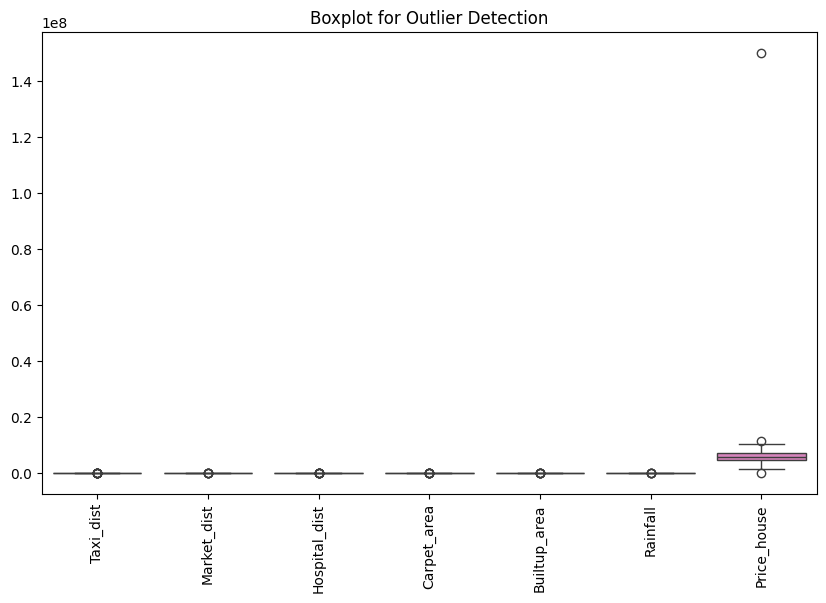

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplot for Outlier Detection')
plt.show()

In [15]:
Q1 = df['Price_house'].quantile(0.25)
Q3 = df['Price_house'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price_house'] < lower) | (df['Price_house'] > upper)]
print(outliers.shape)

(3, 9)


In [17]:
df = df[(df['Price_house'] >= lower) & (df['Price_house'] <= upper)]

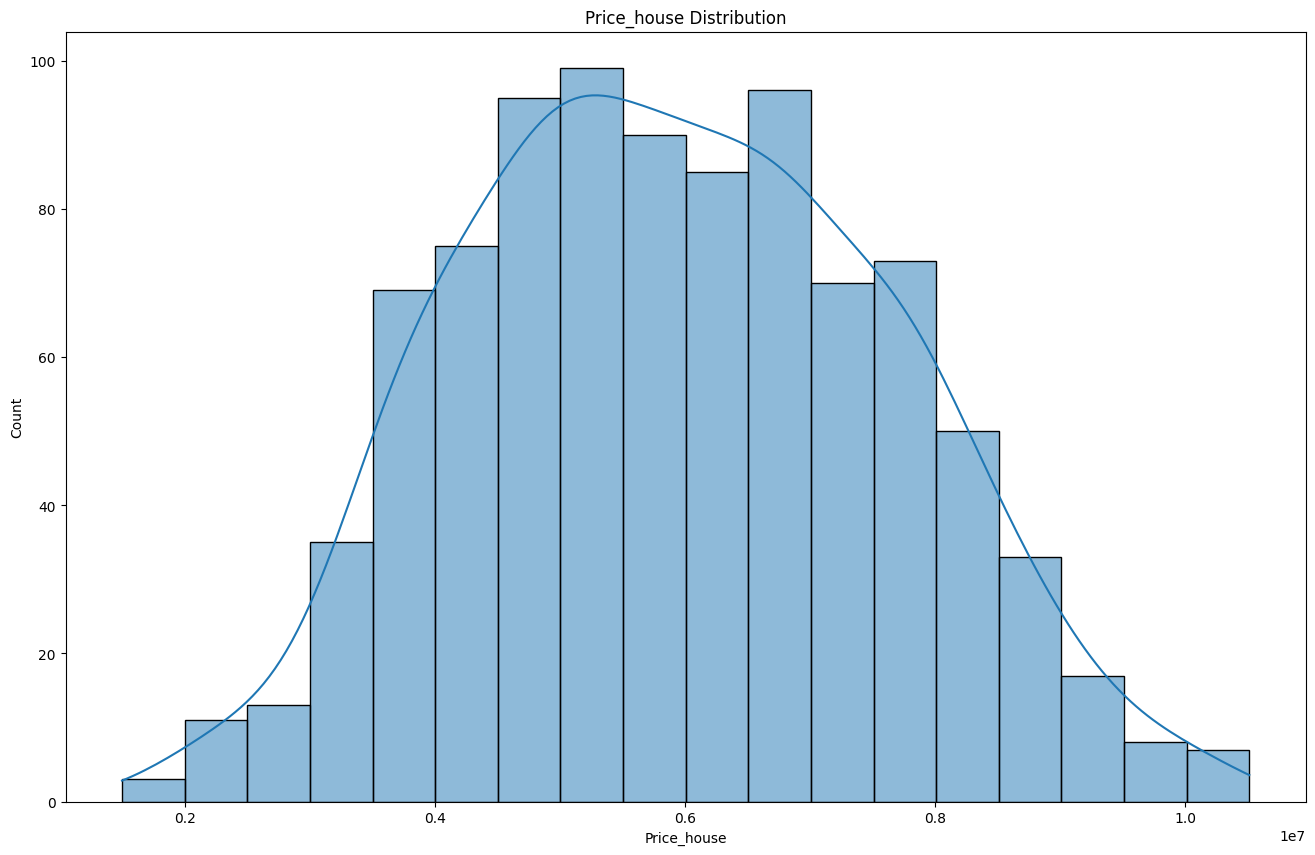

In [18]:
plt.figure(figsize=(16,10))
sns.histplot(df['Price_house'],kde=True)
plt.title('Price_house Distribution')
plt.show()

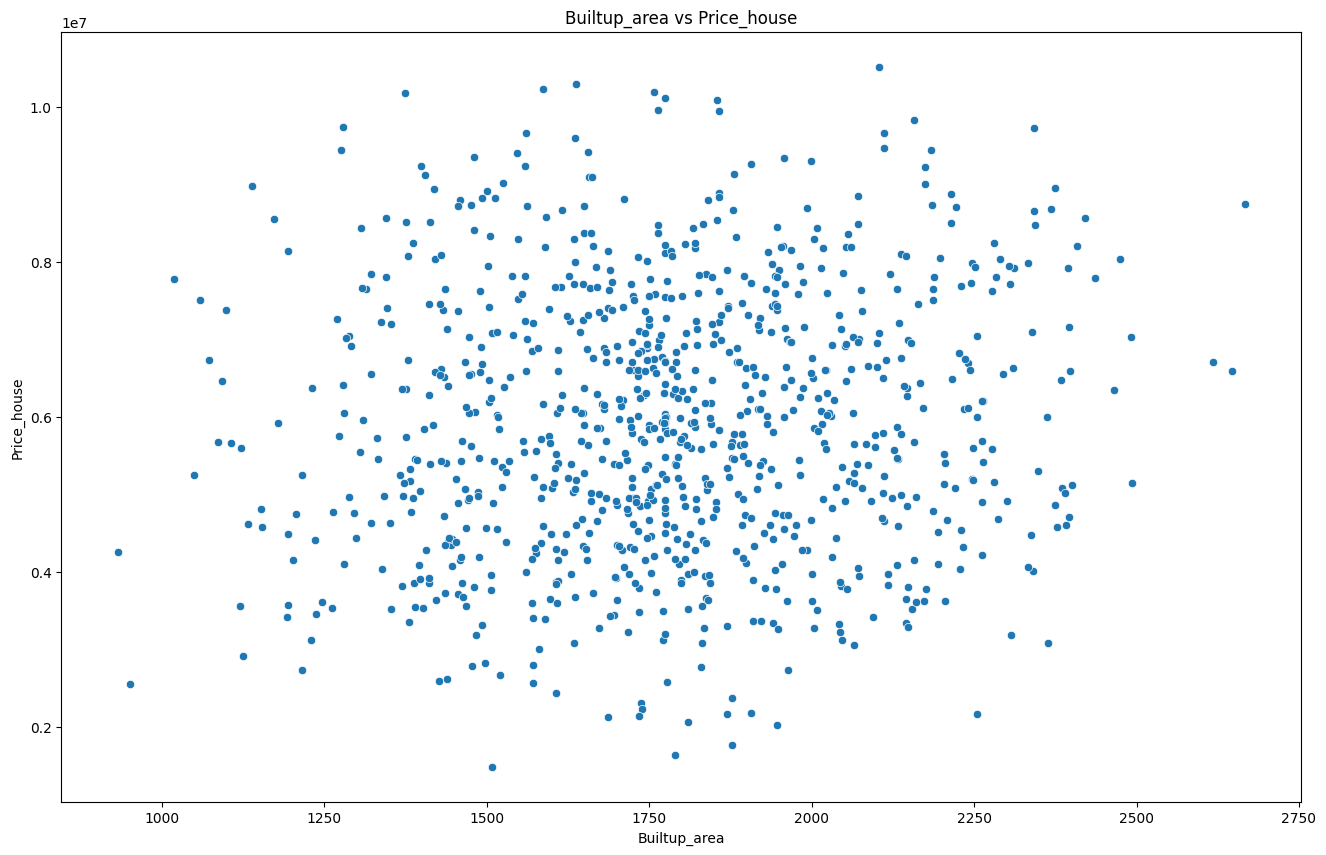

In [19]:
plt.figure(figsize=(16,10))
sns.scatterplot(x=df['Builtup_area'],y=df['Price_house'])
plt.title('Builtup_area vs Price_house')
plt.show()

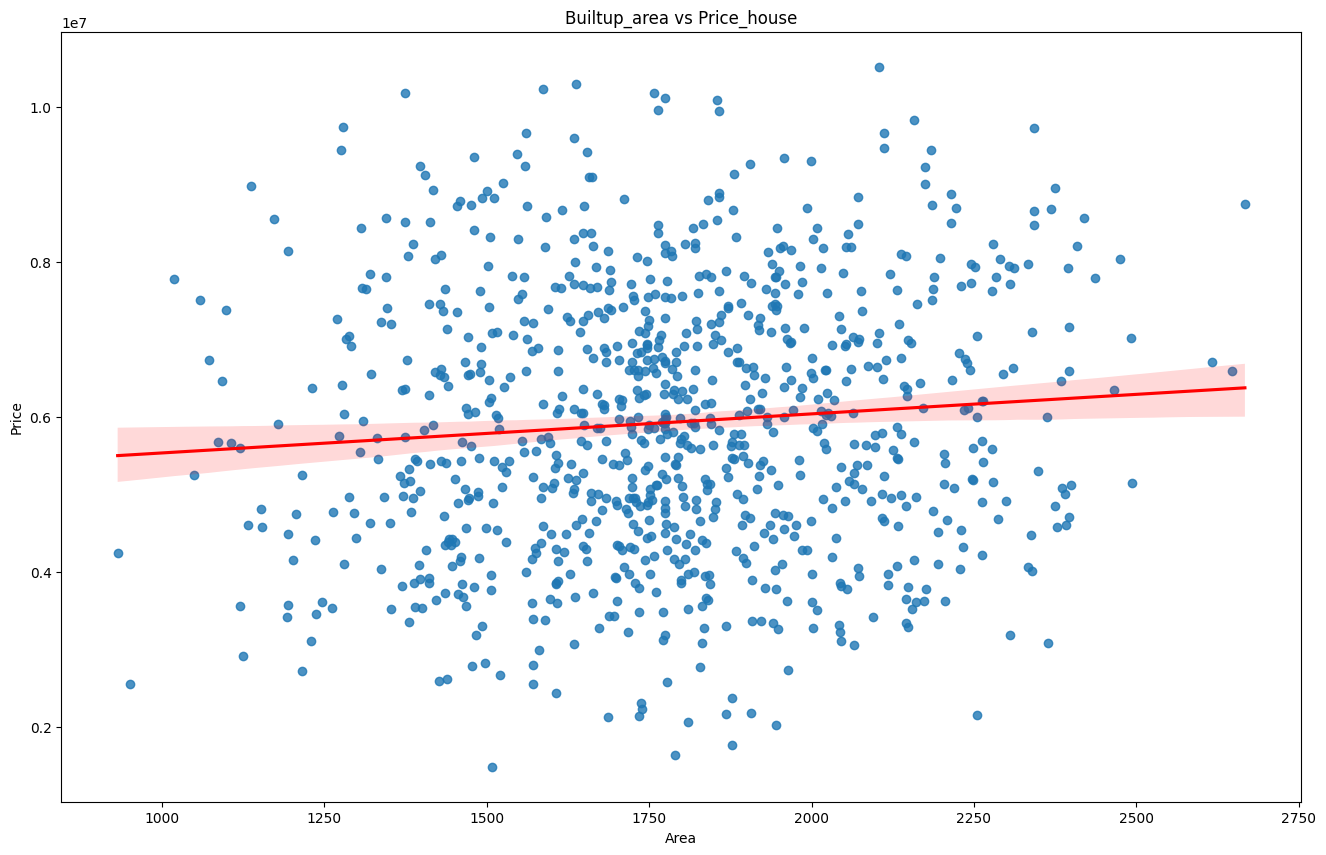

In [21]:
plt.figure(figsize=(16,10))
sns.regplot(x=df['Builtup_area'],y=df['Price_house'], line_kws={'color':'red'})
plt.title('Builtup_area vs Price_house')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

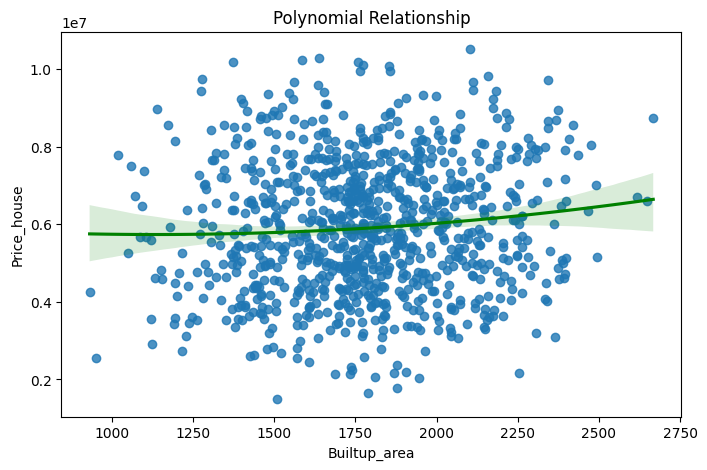

In [22]:
#Polynomial Curve Fit
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Builtup_area'],
    y=df['Price_house'],
    order=2,
    line_kws={'color':'green'}
)

plt.title("Polynomial Relationship")
plt.show()

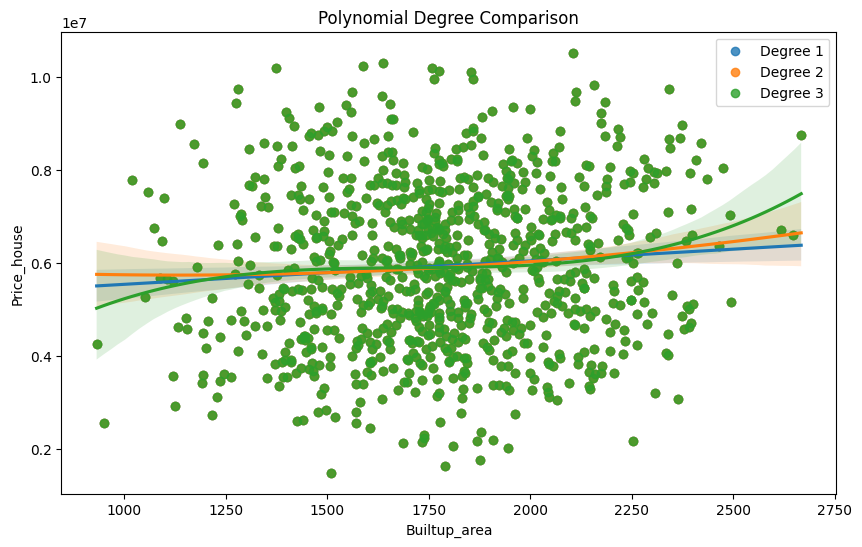

In [23]:
plt.figure(figsize=(10,6))

sns.regplot(x=df['Builtup_area'], y=df['Price_house'], order=1, label='Degree 1')
sns.regplot(x=df['Builtup_area'], y=df['Price_house'], order=2, label='Degree 2')
sns.regplot(x=df['Builtup_area'], y=df['Price_house'], order=3, label='Degree 3')

plt.legend()
plt.title("Polynomial Degree Comparison")
plt.show()

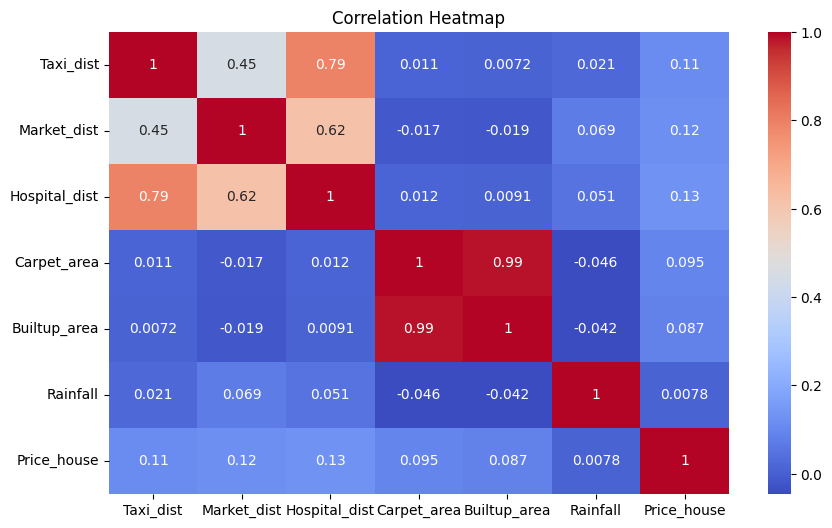

In [25]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

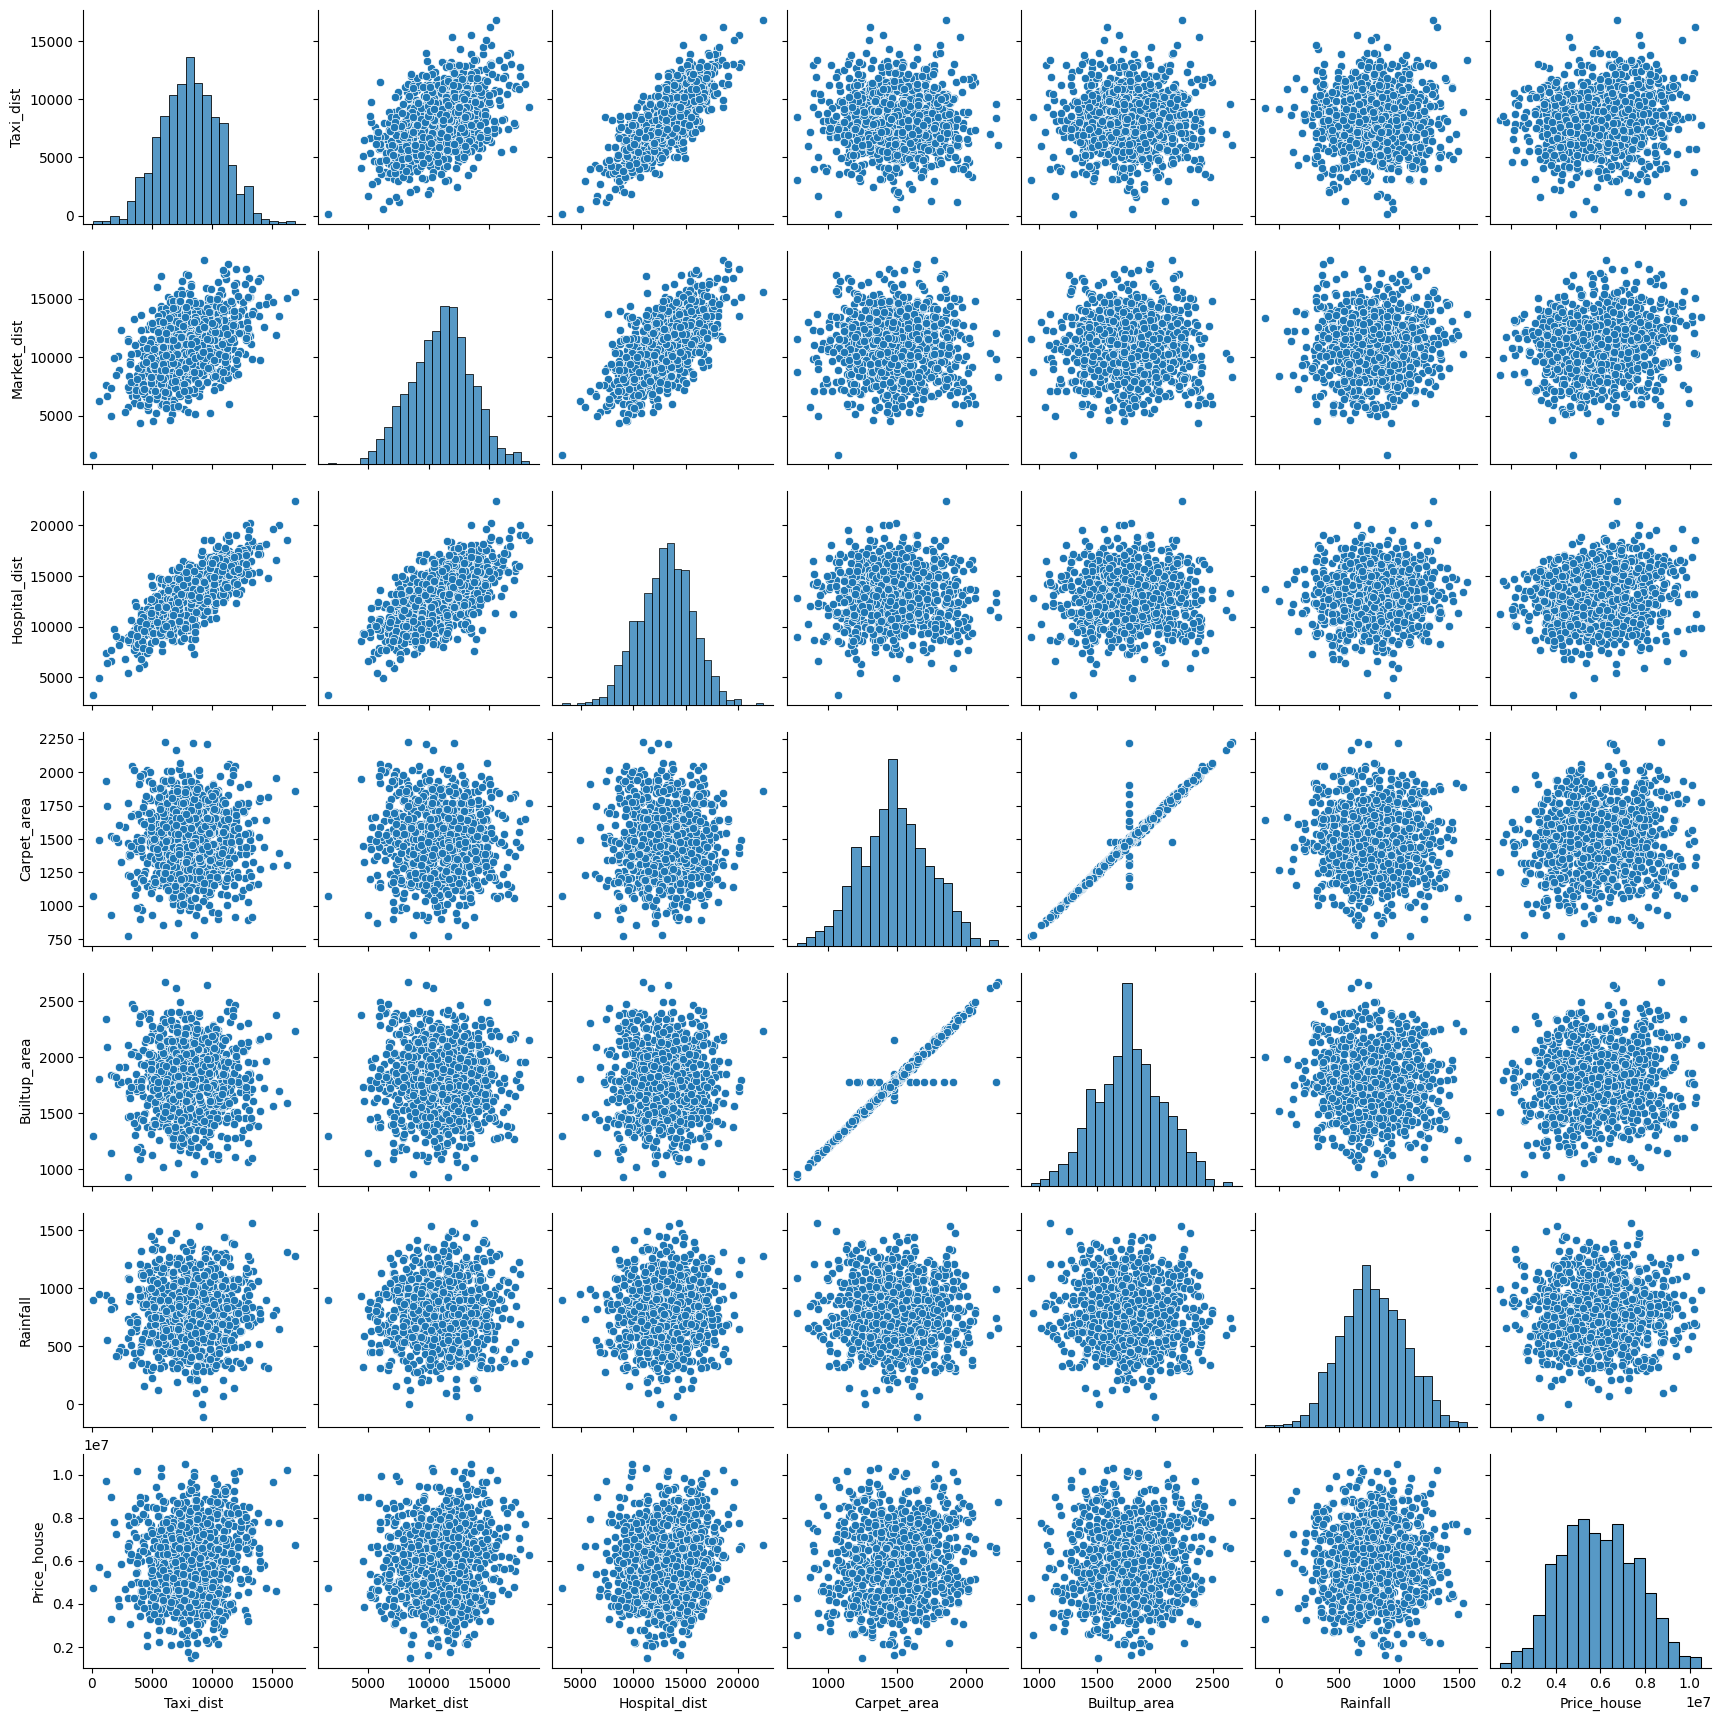

In [26]:
sns.pairplot(df)
plt.show()

In [54]:
X = df[['Carpet_area','Market_dist','Builtup_area','Hospital_dist']]
y = df['Price_house']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [57]:
print(poly.get_feature_names_out())

['1' 'Carpet_area' 'Market_dist' 'Builtup_area' 'Hospital_dist'
 'Carpet_area^2' 'Carpet_area Market_dist' 'Carpet_area Builtup_area'
 'Carpet_area Hospital_dist' 'Market_dist^2' 'Market_dist Builtup_area'
 'Market_dist Hospital_dist' 'Builtup_area^2' 'Builtup_area Hospital_dist'
 'Hospital_dist^2']


In [58]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [59]:
y_pred = model.predict(X_test_poly)

In [60]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 1380688.7572747858


In [61]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2804831007460.736


In [62]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1674762.9705306767


In [63]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.006868114096981182


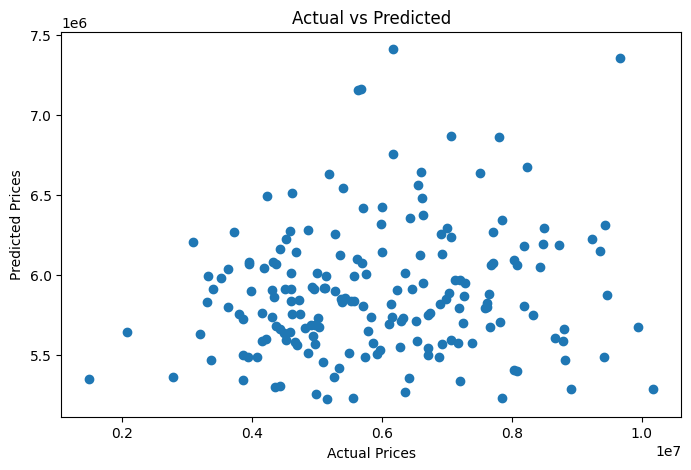

In [64]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

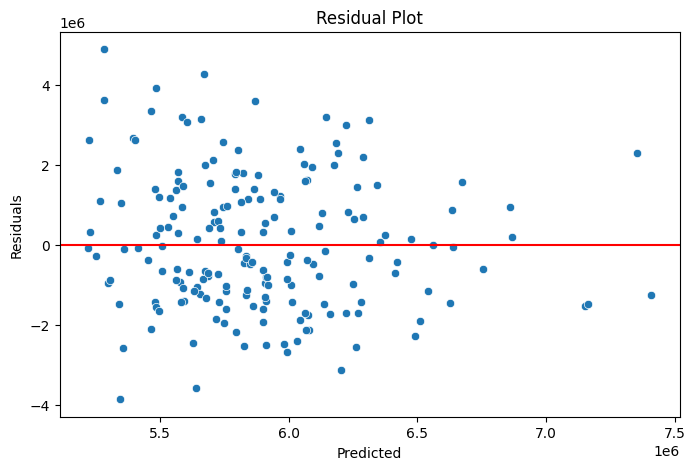

In [65]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

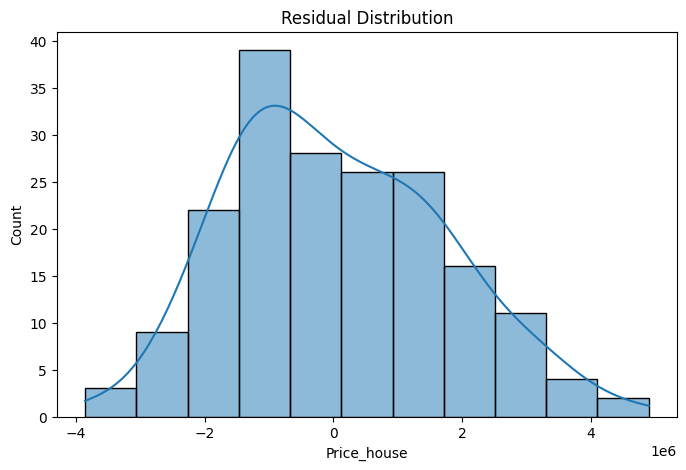

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [42]:
train_scores = []
test_scores = []

degrees = [1,2,3,4,5]

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_scores.append(model.score(X_train_poly, y_train))
    test_scores.append(model.score(X_test_poly, y_test))

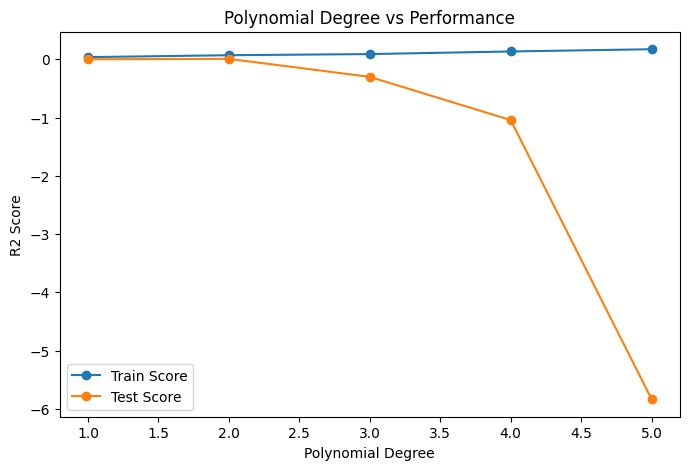

In [43]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_scores, marker='o', label='Train Score')
plt.plot(degrees, test_scores, marker='o', label='Test Score')

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Polynomial Degree vs Performance")
plt.legend()
plt.show()

#model explains only 0.68% variance
#Almost no relationship is being learned
#Model performance is nearly equal to random prediction

#model performance is extremely poor because the data itself has very weak predictive relationships and there are some important modeling issues.
